# 家計簿：カード明細の取り込みと支出の可視化

クレジットカードの利用明細CSVを読み込み，カテゴリ分類・月次集計・グラフ化を行うノートブックです．

## 使い方
- `input/kakeibo_card_statement_sample.csv` にサンプルのカード明細を用意しています．列構成は次の通りです．
  - `利用日`：利用日（`YYYY/MM/DD`）
  - `利用店名・利用先`：店名・利用先
  - `支払方法`：支払方法（今回は可視化には使用しません）
  - `利用金額`：利用金額（円）
- 実際のカード明細を使う場合は，同じ列構成に合わせるか，下の「データ読み込み」セルの列名指定を書き換えてください．
- カテゴリはCSVに含まれていないことが多いため，店名に含まれるキーワードからカテゴリを推定しています．`CATEGORY_KEYWORDS`辞書に自分のよく使う店を追加すれば精度が上がります．


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 日本語フォントの設定（japanize_matplotlibがあれば利用，無ければ代表的な日本語フォント名を試す）
try:
    import japanize_matplotlib  # noqa: F401
except ImportError:
    plt.rcParams["font.family"] = [
        "IPAexGothic", "IPAGothic", "Hiragino Sans", "Yu Gothic", "Meiryo", "TakaoPGothic",
    ]

plt.rcParams["axes.unicode_minus"] = False


## データ読み込み
カード明細CSVを読み込み，日付・金額の型を整えます．


In [2]:
CSV_PATH = "input/kakeibo_card_statement_sample.csv"
COL_DATE = "利用日"
COL_STORE = "利用店名・利用先"
COL_AMOUNT = "利用金額"

df = pd.read_csv(CSV_PATH)
df[COL_DATE] = pd.to_datetime(df[COL_DATE])
df[COL_AMOUNT] = df[COL_AMOUNT].astype(int)
df = df.sort_values(COL_DATE).reset_index(drop=True)

print(f"取引件数: {len(df)}件 / 期間: {df[COL_DATE].min().date()} 〜 {df[COL_DATE].max().date()}")
df.head(10)


取引件数: 134件 / 期間: 2026-05-03 〜 2026-07-31


,利用日,利用店名・利用先,支払方法,利用金額
0,2026-05-03,マクドナルド大井町店,1回払い,1057
1,2026-05-03,東京ガス,リボ払い,3839
2,2026-05-05,西友大井町店,1回払い,1444
3,2026-05-05,スターバックス目黒店,リボ払い,738
4,2026-05-05,TOHOシネマズ品川,リボ払い,1954
5,2026-05-06,東京電力エナジーパートナー,リボ払い,11323
6,2026-05-07,マクドナルド大井町店,リボ払い,1519
7,2026-05-07,サイゼリヤ大森店,1回払い,2657
8,2026-05-07,東京都水道局,2回払い,2653
9,2026-05-07,ソフトバンク光,1回払い,5418


## カテゴリ分類
店名に含まれるキーワードから支出カテゴリを推定します．どのキーワードにも一致しない場合は「その他」に分類されます．


In [3]:
CATEGORY_KEYWORDS = {
    "スーパー": ["イオン", "西友", "ライフ"],
    "コンビニ": ["セブンイレブン", "ファミリーマート", "ローソン"],
    "外食": ["スターバックス", "マクドナルド", "サイゼリヤ", "吉野家", "スシロー"],
    "交通": ["JR", "ENEOS", "Times", "駐車場"],
    "通信": ["ドコモ", "ソフトバンク光", "au", "楽天モバイル"],
    "通販": ["Amazon", "楽天市場"],
    "娯楽": ["Netflix", "TOHOシネマズ", "シネマ"],
    "医療": ["薬局", "クリニック", "病院"],
    "光熱費": ["電力", "ガス", "水道局"],
}


def classify(store_name: str) -> str:
    for category, keywords in CATEGORY_KEYWORDS.items():
        if any(keyword in store_name for keyword in keywords):
            return category
    return "その他"


df["カテゴリ"] = df[COL_STORE].apply(classify)
df[[COL_DATE, COL_STORE, "カテゴリ", COL_AMOUNT]].head(10)


,利用日,利用店名・利用先,カテゴリ,利用金額
0,2026-05-03,マクドナルド大井町店,外食,1057
1,2026-05-03,東京ガス,光熱費,3839
2,2026-05-05,西友大井町店,スーパー,1444
3,2026-05-05,スターバックス目黒店,外食,738
4,2026-05-05,TOHOシネマズ品川,娯楽,1954
5,2026-05-06,東京電力エナジーパートナー,光熱費,11323
6,2026-05-07,マクドナルド大井町店,外食,1519
7,2026-05-07,サイゼリヤ大森店,外食,2657
8,2026-05-07,東京都水道局,光熱費,2653
9,2026-05-07,ソフトバンク光,通信,5418


## 月次・カテゴリ別の集計


In [4]:
df["年月"] = df[COL_DATE].dt.to_period("M").astype(str)

monthly_total = df.groupby("年月")[COL_AMOUNT].sum()
category_total = df.groupby("カテゴリ")[COL_AMOUNT].sum().sort_values(ascending=False)
monthly_category = df.pivot_table(
    index="年月", columns="カテゴリ", values=COL_AMOUNT, aggfunc="sum", fill_value=0
)

print("月別支出合計:")
print(monthly_total)
print()
print("カテゴリ別支出合計:")
print(category_total)


月別支出合計:
年月
2026-05    181949
2026-06    149049
2026-07    180606
Name: 利用金額, dtype: int64

カテゴリ別支出合計:
カテゴリ
光熱費     142664
スーパー     74213
通信       73721
交通       70793
通販       50221
医療       34361
外食       31117
娯楽       23301
コンビニ     11213
Name: 利用金額, dtype: int64


## 可視化1：月別支出推移


findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Hiragino Sans' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'TakaoPGothic' not found.


...

findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Hiragino Sans' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'TakaoPGothic' not found.


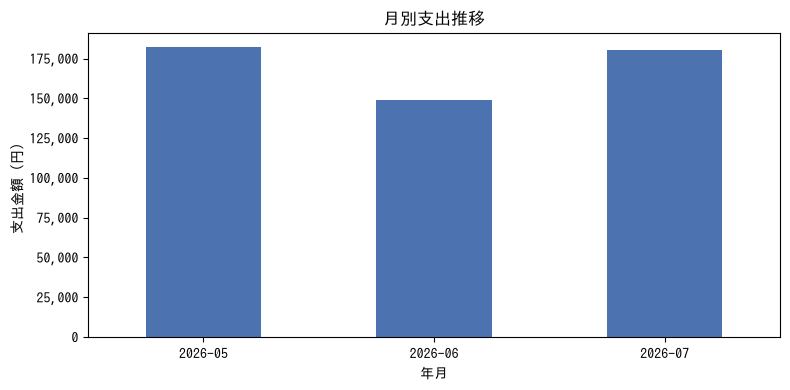

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
monthly_total.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("月別支出推移")
ax.set_xlabel("年月")
ax.set_ylabel("支出金額（円）")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 可視化2：カテゴリ別支出割合


findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Hiragino Sans' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'TakaoPGothic' not found.


...

findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Hiragino Sans' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'TakaoPGothic' not found.


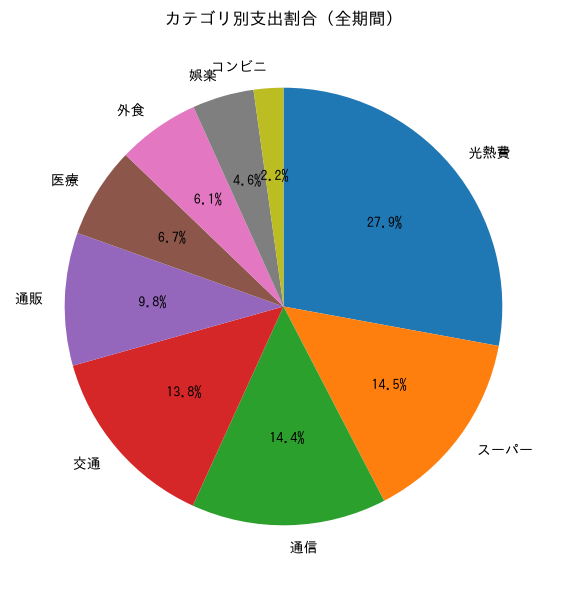

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
category_total.plot(
    kind="pie", ax=ax, autopct="%1.1f%%", startangle=90, counterclock=False,
    ylabel="",
)
ax.set_title("カテゴリ別支出割合（全期間）")
plt.tight_layout()
plt.show()


## 可視化3：カテゴリ別の月次推移


findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Hiragino Sans' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'TakaoPGothic' not found.


...

findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Hiragino Sans' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'TakaoPGothic' not found.


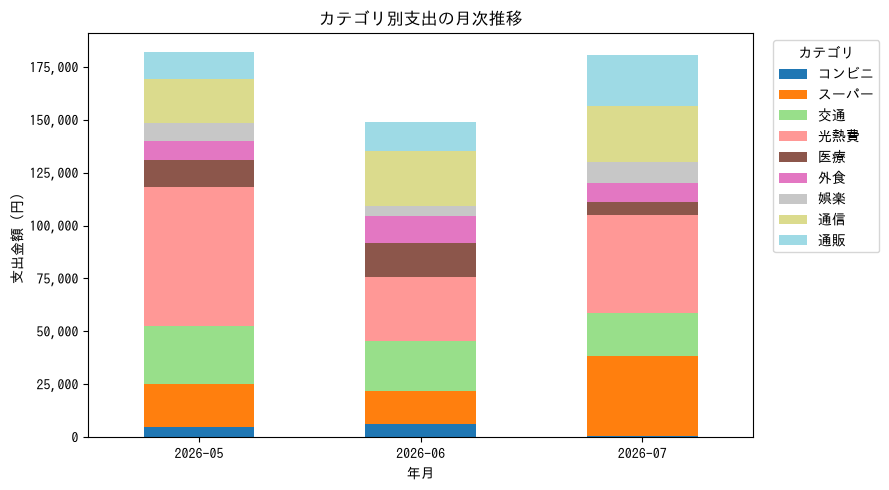

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
monthly_category.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("カテゴリ別支出の月次推移")
ax.set_xlabel("年月")
ax.set_ylabel("支出金額（円）")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="カテゴリ")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 可視化4：高額支出ランキング TOP10


findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Hiragino Sans' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'TakaoPGothic' not found.


...

findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Hiragino Sans' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'TakaoPGothic' not found.


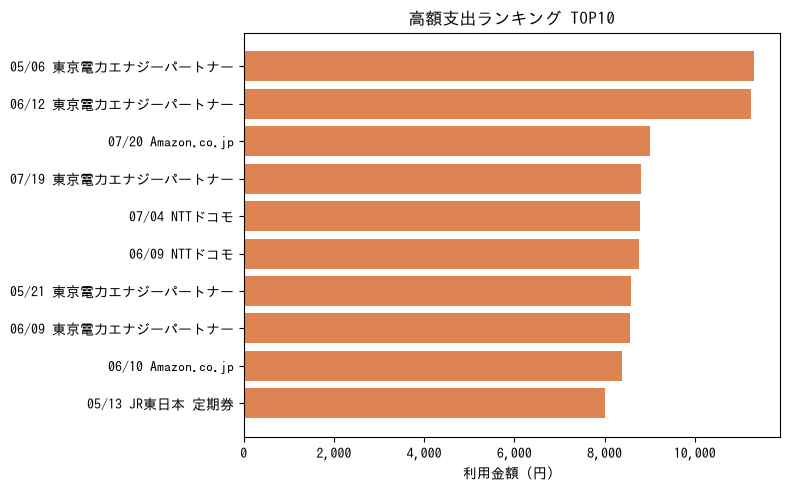

,利用日,利用店名・利用先,カテゴリ,利用金額
5,2026-05-06,東京電力エナジーパートナー,光熱費,11323
65,2026-06-12,東京電力エナジーパートナー,光熱費,11255
117,2026-07-20,Amazon.co.jp,通販,9004
116,2026-07-19,東京電力エナジーパートナー,光熱費,8808
94,2026-07-04,NTTドコモ,通信,8796
60,2026-06-09,NTTドコモ,通信,8770
32,2026-05-21,東京電力エナジーパートナー,光熱費,8577
58,2026-06-09,東京電力エナジーパートナー,光熱費,8553
61,2026-06-10,Amazon.co.jp,通販,8397
20,2026-05-13,JR東日本 定期券,交通,8000


In [8]:
top10 = df.nlargest(10, COL_AMOUNT)[[COL_DATE, COL_STORE, "カテゴリ", COL_AMOUNT]]
labels = top10[COL_DATE].dt.strftime("%m/%d") + " " + top10[COL_STORE]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(labels[::-1], top10[COL_AMOUNT][::-1], color="#DD8452")
ax.set_title("高額支出ランキング TOP10")
ax.set_xlabel("利用金額（円）")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

top10
